In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# imports for the libraries that i will use

In [19]:
df = pd.read_csv("final_internship_data.csv")
df.head()
# for loading the data and show me the first five rows

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [20]:
print("Dataset Shape:", df.shape)
# for know how many rows and coiumns in the csv file

Dataset Shape: (500000, 26)


In [21]:
df.info()
# show me the types that data contains

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [22]:
missing = df.isnull().sum()
print(missing)
# sho me how many missing elements in each column

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64


In [23]:
columns_to_drop = [
    "User ID",
    "User Name",
    "Driver Name"
]

df.drop(columns=columns_to_drop, inplace=True)
#drop useless columns

In [24]:
df.head()

,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [25]:
df.drop_duplicates(subset="key", inplace=True)
print(df.duplicated().sum())
# drop the duplicates using key because it is use only for deduplication

0


In [ ]:
df.drop(columns=["key"], inplace=True)

In [26]:
df.head()

,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [27]:
print(df.duplicated().sum())

0


In [28]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358361,-1.265712,0.696740,-1.265755,0.696675,1.683428,13.510834,15.684206,6.268650,3.042008,2011.739132,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916617,0.206941,0.140909,0.205903,0.128997,1.307395,6.511571,8.681066,3.437815,1.949240,1.860889,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


In [29]:
df.dropna(inplace=True)

In [30]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)
# this is for show which columns contain objects(string)

Index(['Car Condition', 'Weather', 'Traffic Condition', 'key',
       'pickup_datetime'],
      dtype='object')


In [31]:
for col in categorical_columns:
    print(f"\n{df[col].value_counts()}")
    # this is a loop that will loop arount the 4 object c olumn to show me how many values each column contains
    # to know if i will use one _hot encoding or label encoding


Car Condition
Very Good    125310
Bad          124977
Good         124967
Excellent    124741
Name: count, dtype: int64

Weather
sunny     100433
cloudy    100060
rainy      99971
stormy     99955
windy      99576
Name: count, dtype: int64

Traffic Condition
Congested Traffic    166846
Dense Traffic        166581
Flow Traffic         166568
Name: count, dtype: int64

key
2010-04-12 23:46:58.0000002      1
2009-06-15 17:26:21.0000001      1
2010-01-05 16:52:16.0000002      1
2011-08-18 00:35:00.00000049     1
2012-04-21 04:30:42.0000001      1
                                ..
2013-11-23 12:57:00.000000190    1
2011-04-05 17:11:05.0000001      1
2013-07-02 19:54:00.000000232    1
2009-11-06 01:04:03.0000002      1
2012-12-24 11:24:00.00000098     1
Name: count, Length: 499995, dtype: int64

pickup_datetime
2012-01-28 13:38:00    6
2012-01-26 21:22:00    6
2014-07-25 19:25:00    5
2010-01-11 18:54:00    5
2012-03-31 23:19:00    5
                      ..
2011-05-27 22:39:21    1
2015-0

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_columns = [
    "Weather",
    "Traffic Condition",
    "Car Condition"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
 # this for make label encoding just for this three columns (Car Condition ,Weather, Traffic Condition )

In [33]:
df.head()

,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,3,4,0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,1,0,2,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,0,2,0,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,3,2,2,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,0,2,0,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [34]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
#this code is for transfering pickup_datetime from object to date

In [35]:
df.head()

,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,3,4,0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,1,0,2,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,0,2,0,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,3,2,2,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,0,2,0,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


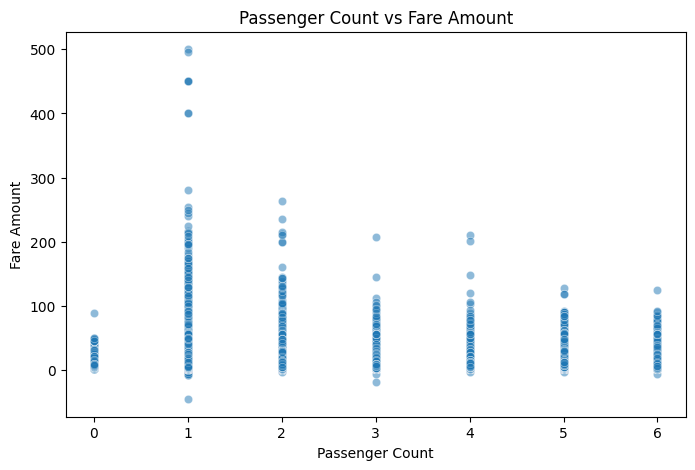

In [36]:
#Q1. Is higher passenger count associated with higher fare؟
# because both passenger_count and fare_amount are numerical variables. It helps identify whether there is a relationship or correlation between the numbers
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="passenger_count",
    y="fare_amount",
    alpha=0.5
)

plt.title("Passenger Count vs Fare Amount")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.show()

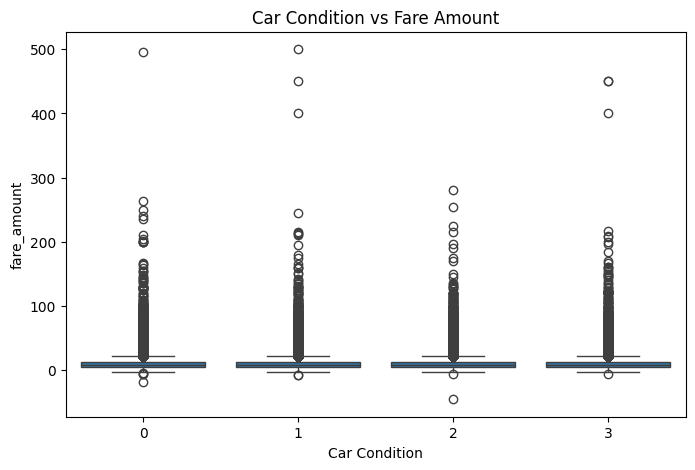

In [37]:
#Q2. Does car condition influence the fare amount?
#A box plot is appropriate
#Why ? because Car Condition is a categorical variable while Fare_Amount is numerical and allows us to compare the outliers of fare amounts across different car conditions
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Car Condition",
    y="fare_amount"
)

plt.title("Car Condition vs Fare Amount")
plt.show()

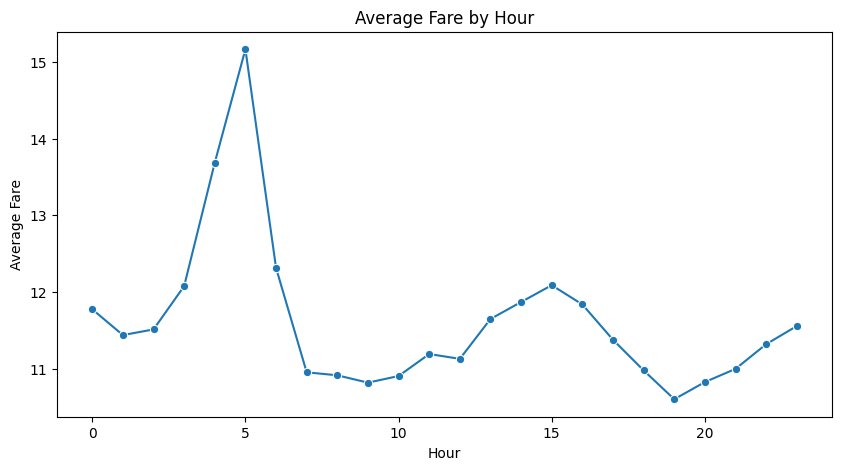

In [38]:
#Q3. At what hour of the day are fares typically highest?
#A line plot is suitable because Hour is an ordered numerical variable representing time and shows how the average fare changes throughout the day
hourly_fare = df.groupby("hour")["fare_amount"].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_fare.index,
    y=hourly_fare.values,
    marker="o"
)

plt.title("Average Fare by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Fare")
plt.show()

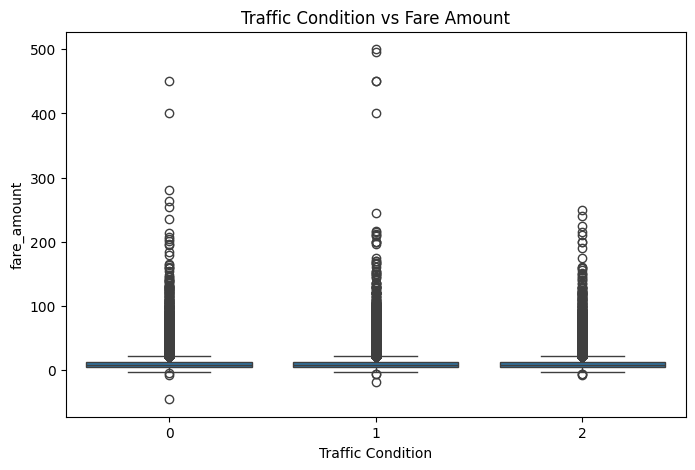

In [39]:
#Q4. Does traffic condition affect the trip fare?
#A box plot is the best choice because Traffic Condition is categorical and Fare_Amount is numerical and allows us to compare the outliers of fare amounts across different traffic conditions
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Traffic Condition",
    y="fare_amount"
)

plt.title("Traffic Condition vs Fare Amount")
plt.show()

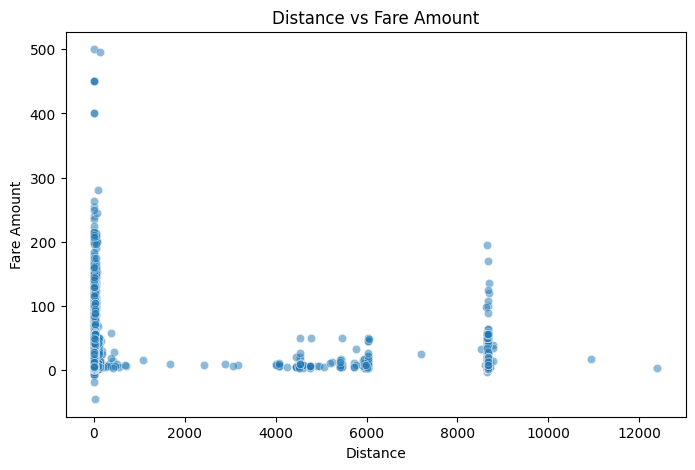

In [40]:
#Q5. Is trip distance the strongest predictor of the fare amount
#A scatter plot is appropriate because both Distance and Fare_Amount are numerical variables and visualize whether fare increases as trip distance increases
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare_amount",
    alpha=0.5
)

plt.title("Distance vs Fare Amount")
plt.xlabel("Distance")
plt.ylabel("Fare Amount")
plt.show()

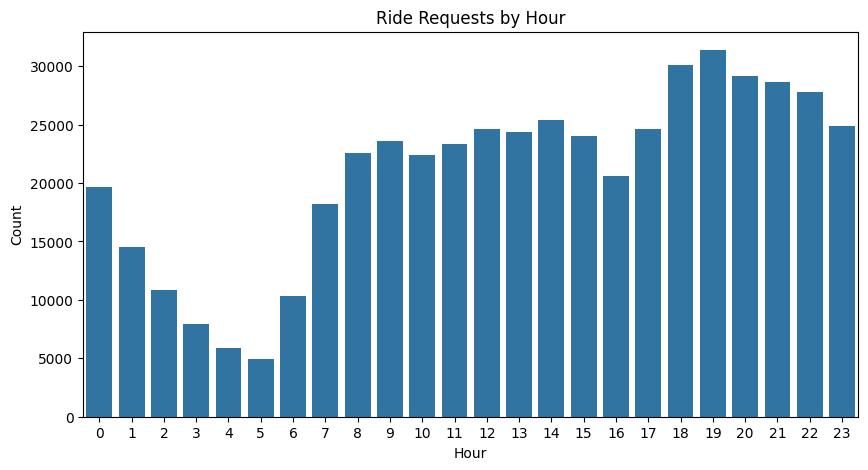

In [41]:
#Q6. At what time of day are ride requests most frequent?
#A count plot is ideal because we want to count the number of rides occurring during each hour of the day not want the avg
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="hour"
)

plt.title("Ride Requests by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

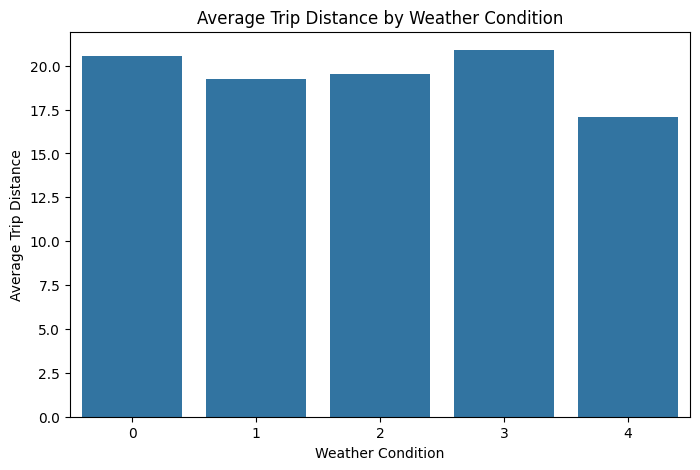

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

#Q7. Does weather condition influence the average trip distance?
#A bar plot is appropriate because Weather is a categorical variable and Distance is a numerical variable  and It displays the average trip distance for each weather condition
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Weather",
    y="distance",
    estimator="mean",
    errorbar=None
)

plt.title("Average Trip Distance by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Trip Distance")
plt.show()

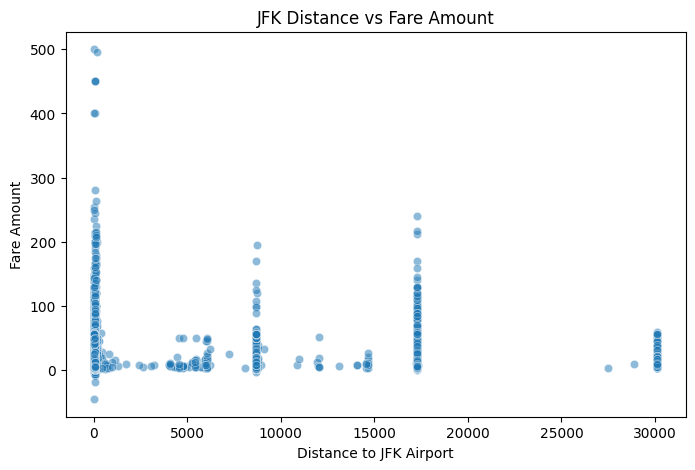

In [43]:
#Q8. Are rides that start closer to airports generally more expensive?
#A scatter plot is appropriate because both JFK_Dist and Fare_Amount are numerical variables and It helps determine whether there is a relationship between airport proximity and fare amount
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="jfk_dist",
    y="fare_amount",
    alpha=0.5
)

plt.title("JFK Distance vs Fare Amount")
plt.xlabel("Distance to JFK Airport")
plt.ylabel("Fare Amount")
plt.show()

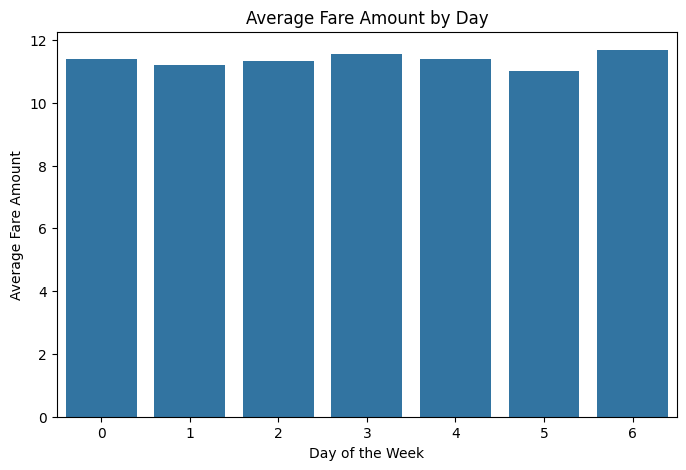

In [44]:
#Q9. Does the day of the week affect the average fare amount?
#A bar plot is appropriate because Day is a categorical/discrete variable and Fare_Amount is numerical and It compares the average fare across different days of the week
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="weekday",
    y="fare_amount",
    errorbar=None
)

plt.title("Average Fare Amount by Day")
plt.xlabel("Day of the Week")
plt.ylabel("Average Fare Amount")
plt.show()

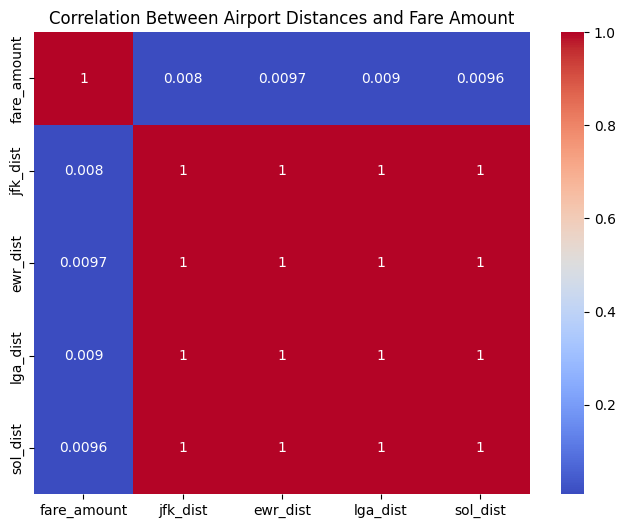

In [45]:
#Q10. Which airport is associated with the highest fares?
#A correlation heatmap helps compare the relationship between the fare amount and the distances to different airports (JFK, EWR, LGA, SOL), making it easier to identify which airport distance has the strongest correlation with fare
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["fare_amount","jfk_dist","ewr_dist","lga_dist","sol_dist"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Airport Distances and Fare Amount")
plt.show()

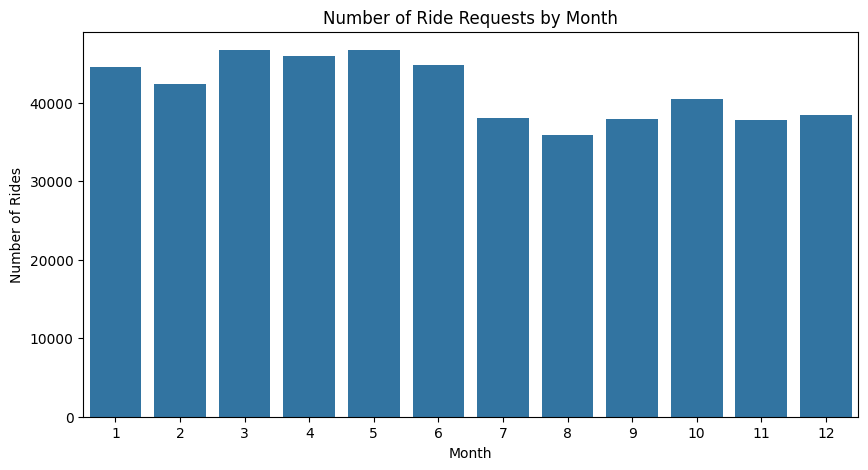

In [46]:
#Q11. Does the pickup month affect the number of ride requests؟
#A count plot is appropriate because Month is a discrete variable  and It displays the number of ride requests in each month
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="month"
)

plt.title("Number of Ride Requests by Month")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.show()

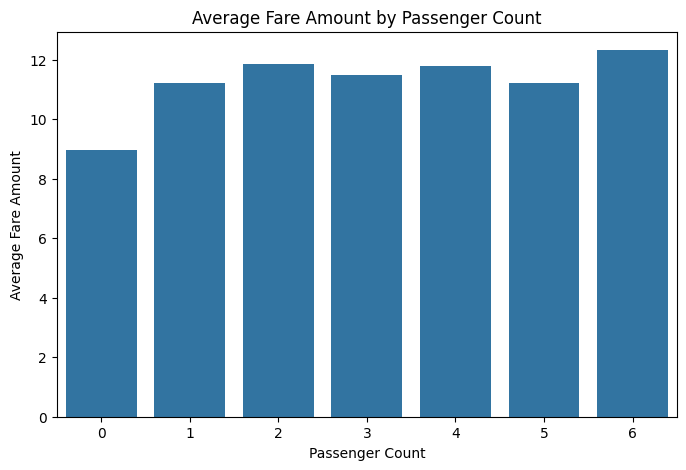

In [47]:
#Q12. Does the number of passengers affect the average fare amount?
#A bar plot is suitable because Passenger_Count is a discrete numerical variable and Fare_Amount is numerical and It compares the average fare amount for different passenger counts.
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="passenger_count",
    y="fare_amount",
    errorbar=None
)

plt.title("Average Fare Amount by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Average Fare Amount")
plt.show()

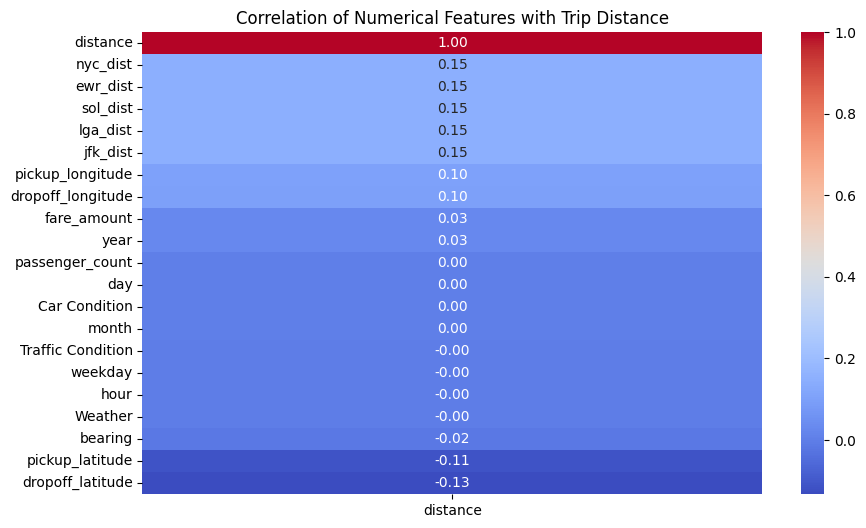

In [48]:
#Q13. Which numerical features have the strongest correlation with trip distance?
#A heatmap is appropriate because it visualizes the correlation coefficients between Distance and other numerical features. It helps identify which variables are most strongly associated with trip distance
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr[["distance"]].sort_values(by="distance", ascending=False),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Numerical Features with Trip Distance")
plt.show()

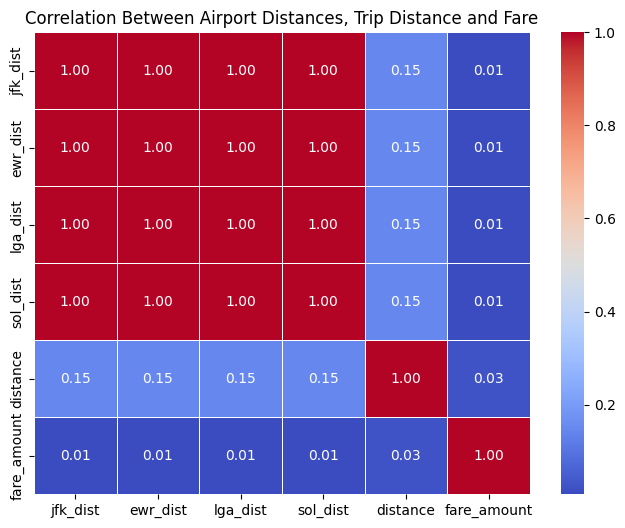

In [49]:
#Q14. How do airport distances correlate with fare amount and trip distance?
#A heatmap is appropriate because it visualizes the correlation between airport distance features, trip distance, and fare amount  and This helps identify which airport distance is most strongly associated with the trip fare and overall travel distance
plt.figure(figsize=(8,6))

airport_features = df[
    ["jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "distance", "fare_amount"]
].corr()

sns.heatmap(
    airport_features,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Airport Distances, Trip Distance and Fare")
plt.show()

In [54]:

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["month"].apply(get_season)

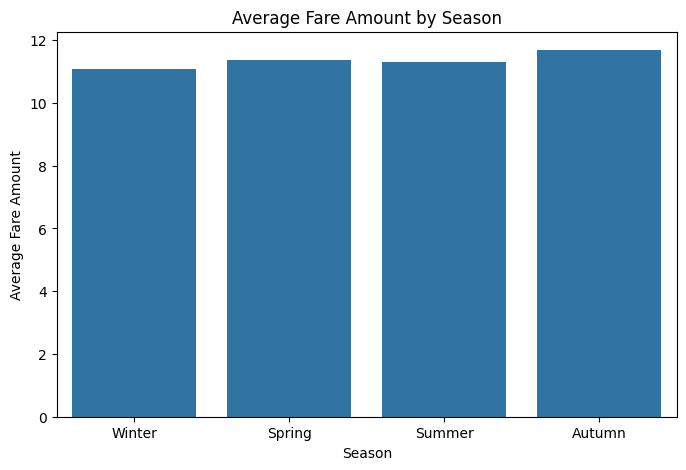

In [53]:
#Q15. Does the season affect the average fare amount?
#A bar plot is appropriate because Season is a categorical variable and Fare_Amount is a numerical variable. It compares the average fare amount across different seasons, making it easy to identify seasonal variations in pricing.
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="fare_amount",
    order=["Winter", "Spring", "Summer", "Autumn"],
    estimator="mean",
    errorbar=None
)

plt.title("Average Fare Amount by Season")
plt.xlabel("Season")
plt.ylabel("Average Fare Amount")

plt.show()